# snRNA cross-cohort QC metrics comparison

Compare SIMPlex specimens vs external references using a **single cohort taxonomy** on every figure.

**Cohorts** (colour/fill): `SIMPlex BC FFPE`, `SIMPlex BC FF`, `SIMPlex PC FFPE`, `SIMPlex Mouse FF`, `SIMPlex Ctrl FFPE`, `SIMPlex Ctrl FF`, `snPatho FFPE`, `10X FFPE`.

**Samples** (`sample_id`): individual libraries shown on the breast-focused figure (one violin per sample, coloured by cohort).
The cross-cohort figure pools samples within each cohort (one violin per cohort, same colours).

Outputs: `qc_cohort_comparison`, `qc_breast_cohort_comparison`, `qc_cohort_summary.csv` under `figs/technical/metrics_comparison/`.

**Prerequisite:** technical `*_noDoublets.rds` from `qc_doubletRemoval.ipynb`.

**Environment:** `simplex` conda env (kernel **R (simplex renv)**).


## Set up


In [1]:
source(here::here("config.R"))
set.seed(1)


## Load libraries


In [2]:
suppressMessages(require(Seurat))
suppressMessages(require(Matrix))
suppressMessages(require(dplyr))
suppressMessages(require(tidyr))
suppressMessages(require(stringr))
suppressMessages(require(magrittr))
suppressMessages(require(patchwork))
suppressMessages(require(ggplot2))
suppressMessages(require(ggpubr))


Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘ggpubr’”


## Config

Toggle cohorts on/off. Tier 2 extracts per-nucleus QC columns only (no Seurat merge).


In [3]:
INCLUDE_BREAST    <- TRUE
INCLUDE_PROSTATE  <- TRUE
INCLUDE_MOUSE     <- TRUE
INCLUDE_TECHNICAL <- TRUE
INCLUDE_SNPATHO   <- TRUE
INCLUDE_10X_BC    <- TRUE
INCLUDE_10X_MOUSE <- TRUE

COHORT_LEVELS <- c(
  "SIMPlex BC FFPE",
  "SIMPlex BC FF",
  "SIMPlex PC FFPE",
  "SIMPlex Mouse FF",
  "SIMPlex Ctrl FFPE",
  "SIMPlex Ctrl FF",
  "snPatho FFPE",
  "10X FFPE"
)

COHORT_COLORS <- c(
  "SIMPlex BC FFPE"    = "#5B4B8A",
  "SIMPlex BC FF"      = "#7B6BA8",
  "SIMPlex PC FFPE"    = "#7B68EE",
  "SIMPlex Mouse FF"   = "#9370DB",
  "SIMPlex Ctrl FFPE" = "#E8923A",
  "SIMPlex Ctrl FF"    = "#F4A460",
  "snPatho FFPE"       = "#3A7CA5",
  "10X FFPE"           = "#2E7D6E"
)

BREAST_FIGURE_COHORTS <- c(
  "SIMPlex BC FFPE", "SIMPlex BC FF", "snPatho FFPE",
  "SIMPlex Ctrl FFPE", "SIMPlex Ctrl FF", "10X FFPE"
)

TECH_SAMPLE_LABELS <- c(
  patient6_technical_3x = "patient6_Ctrl_3x",
  patient4_technical = "patient4_Ctrl",
  patient10_technical1 = "patient10_rep1_Ctrl",
  patient10_technical2 = "patient10_rep2_Ctrl"
)
TECH_SAMPLE_COHORTS <- c(
  patient6_technical_3x = "SIMPlex Ctrl FFPE",
  patient4_technical = "SIMPlex Ctrl FFPE",
  patient10_technical1 = "SIMPlex Ctrl FF",
  patient10_technical2 = "SIMPlex Ctrl FF"
)
TECH_SAMPLES <- names(TECH_SAMPLE_LABELS)

FIG_DIR <- file.path(FIGS_ROOT, "technical", "metrics_comparison")
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)


## Tier 1 — CellRanger / CellBender CSV metrics (technical controls)

Read per-sample summary CSVs and inspect side-by-side.


In [4]:
# CellRanger: multi-sample outs/.../<sample>/metrics_summary.csv OR singleplex <sample>/metrics_summary.csv
# CellBender: CELLBENDER/technical_experiments/<sample>/<sample>_cellbender_metrics.csv

technical_cellranger_metrics <- function(sample) {
  candidates <- c(
    file.path(
      CELLRANGER, "technical_experiments", sample,
      "outs", "per_sample_outs", sample, "metrics_summary.csv"
    ),
    file.path(CELLRANGER, "technical_experiments", sample, "metrics_summary.csv")
  )
  hit <- candidates[file.exists(candidates)][1]
  if (is.na(hit)) NULL else read.csv(hit)
}

tier1 <- lapply(TECH_SAMPLES, function(sample) {
  cb_path <- file.path(
    CELLBENDER, "technical_experiments", sample,
    paste0(sample, "_cellbender_metrics.csv")
  )
  list(
    sample = sample,
    plot_label = unname(TECH_SAMPLE_LABELS[sample]),
    cellranger = technical_cellranger_metrics(sample),
    cellbender = if (file.exists(cb_path)) read.csv(cb_path) else NULL
  )
})
tier1


Category,Library.Type,Grouped.By,Group.Name,Metric.Name,Metric.Value
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Cells,Gene Expression,,,Cells,"4,584"
Cells,Gene Expression,,,Confidently mapped reads in cells,85.68%
Cells,Gene Expression,,,Estimated UMIs from genomic DNA,0.20%
Cells,Gene Expression,,,Estimated UMIs from genomic DNA per unspliced probe,1
Cells,Gene Expression,,,Median UMI counts per cell,"2,223"
Cells,Gene Expression,,,Median genes per cell,"1,377"
Cells,Gene Expression,,,Median reads per cell,"7,422"
Cells,Gene Expression,,,Number of reads from cells called from this sample,"52,105,967"
Cells,Gene Expression,,,Reads confidently mapped to filtered probe set,94.01%


## Tier 2 — Load, extract QC metrics, plot

Each object is tagged at load with `cohort` (8 levels in Config) and `sample_id` (library / patient).

| Cohort | Source | `sample_id` |
|--------|--------|-------------|
| SIMPlex BC FFPE | `SIMPlex_breast_allSamples.rds` | one per FFPE breast patient |
| SIMPlex BC FF | `other/patient10_seuratAnnotation.rds` | `patient10_FF_18um` |
| SIMPlex PC FFPE | `pt10_HD` + `pt20_HD` RDS | `pt10_HD`, `pt20_HD` |
| SIMPlex Mouse FF | `mouse_brain/snRNA.rds` | single library |
| SIMPlex Ctrl FFPE / FF | technical `*_noDoublets.rds` | `TECH_SAMPLE_LABELS`; cohort via `TECH_SAMPLE_COHORTS` |
| snPatho FFPE | snPATHO integrated RDS (FFPE) | `sample_id` per patient |
| 10X FFPE | public 10x h5 (BC + mouse) | one label per reference |


In [5]:
# Per-object metadata only — avoids holding merged Seurat objects in memory.
extract_qc_df <- function(obj) {
  md <- obj[[]]
  stopifnot(all(c("cohort", "sample_id", "nFeature_RNA", "nCount_RNA") %in% colnames(md)))
  data.frame(
    cohort = as.character(md$cohort),
    sample_id = as.character(md$sample_id),
    nFeature_RNA = as.numeric(md$nFeature_RNA),
    nCount_RNA = as.numeric(md$nCount_RNA),
    stringsAsFactors = FALSE
  )
}

qc_frames <- list()

if (INCLUDE_BREAST) {
  qc <- readRDS(file.path(SN_RDS, "breast_cancer/cross_patient/SIMPlex_breast_allSamples.rds"))
  qc$cohort <- "SIMPlex BC FFPE"
  qc$sample_id <- paste0("BC_", qc$sample)
  qc_frames$breast <- extract_qc_df(qc)
  rm(qc); gc()

  p10_ff_path <- file.path(SN_RDS, "breast_cancer/other/patient10_seuratAnnotation.rds")
  if (file.exists(p10_ff_path)) {
    p10_ff <- readRDS(p10_ff_path)
    p10_ff$cohort <- "SIMPlex BC FF"
    p10_ff$sample_id <- "patient10_FF_18um"
    qc_frames$patient10_ff <- extract_qc_df(p10_ff)
    rm(p10_ff); gc()
  } else {
    warning("patient10 FF object not found: ", p10_ff_path)
  }
}

if (INCLUDE_PROSTATE) {
  prost1 <- readRDS(file.path(SN_RDS, "prostate_cancer/pt10_HD_seuratAnnotation.rds"))
  prost1$cohort <- "SIMPlex PC FFPE"
  prost1$sample_id <- "pt10_HD"
  prost2 <- readRDS(file.path(SN_RDS, "prostate_cancer/pt20_HD_seuratAnnotation.rds"))
  prost2$cohort <- "SIMPlex PC FFPE"
  prost2$sample_id <- "pt20_HD"
  qc_frames$prostate <- dplyr::bind_rows(extract_qc_df(prost1), extract_qc_df(prost2))
  rm(prost1, prost2); gc()
}

if (INCLUDE_MOUSE) {
  mouse <- readRDS(file.path(SN_RDS, "mouse_brain/snRNA.rds"))
  mouse$cohort <- "SIMPlex Mouse FF"
  mouse$sample_id <- "SIMPlex mouse"
  qc_frames$mouse <- extract_qc_df(mouse)
  rm(mouse); gc()
}

if (INCLUDE_TECHNICAL) {
  tech_frames <- lapply(TECH_SAMPLES, function(s) {
    label <- unname(TECH_SAMPLE_LABELS[s])
    path <- file.path(SN_RDS, "technical_experiments", paste0(s, "_noDoublets.rds"))
    if (!file.exists(path)) {
      warning("Skipping ", s, " (", label, "): ", path, " not found")
      return(NULL)
    }
    obj <- readRDS(path)
    obj$cohort <- unname(TECH_SAMPLE_COHORTS[s])
    obj$sample_id <- label
    df <- extract_qc_df(obj)
    rm(obj)
    df
  })
  tech_frames <- tech_frames[!vapply(tech_frames, is.null, logical(1))]
  stopifnot(length(tech_frames) > 0L)
  qc_frames$technical <- dplyr::bind_rows(tech_frames)
  rm(tech_frames); gc()
}

if (INCLUDE_SNPATHO) {
  snpatho_files <- sort(list.files(
    file.path(EXT_REFS, "snPATHO"),
    pattern = "_integrated_seuarat_object\\.rds$",
    full.names = TRUE
  ))
  stopifnot(length(snpatho_files) > 0L)
  qc_frames$snpatho <- dplyr::bind_rows(lapply(snpatho_files, function(f) {
    obj <- readRDS(f)
    stopifnot("sample_id" %in% colnames(obj[[]]))
    obj <- subset(obj, subset = processing_method == "FFPE_snPATHO")
    obj$cohort <- "snPatho FFPE"
    obj$sample_id <- as.character(obj$sample_id)
    df <- extract_qc_df(obj)
    rm(obj)
    df
  }))
  gc()
}

if (INCLUDE_10X_BC) {
  tenx <- Read10X_h5(file.path(
    EXT_REFS,
    "10x_BC_FFPE/320k_scFFPE_16-plex_GEM-X_FLEX_BreastCancer1_BC7-8_count_sample_filtered_feature_bc_matrix.h5"
  ))
  tenx <- CreateSeuratObject(counts = tenx)
  tenx$cohort <- "10X FFPE"
  tenx$sample_id <- "10X FFPE BC"
  qc_frames$tenx_bc <- extract_qc_df(tenx)
  rm(tenx); gc()
}

if (INCLUDE_10X_MOUSE) {
  mfb <- Read10X_h5(file.path(
    EXT_REFS,
    "mouse_forebrain_10x/10k_mouse_forebrain_scFFPE_singleplex_count_sample_filtered_feature_bc_matrix.h5"
  ))
  mfb <- CreateSeuratObject(counts = mfb)
  mfb$cohort <- "10X FFPE"
  mfb$sample_id <- "10X mouse forebrain"
  qc_frames$tenx_mouse <- extract_qc_df(mfb)
  rm(mfb); gc()
}

qc_meta <- dplyr::bind_rows(qc_frames)
rm(qc_frames); gc()

qc_meta$cohort <- factor(qc_meta$cohort, levels = COHORT_LEVELS)
qc_meta$log10_nCount <- log10(qc_meta$nCount_RNA + 1)

stopifnot(!any(is.na(qc_meta$cohort)), !any(is.na(qc_meta$sample_id) | qc_meta$sample_id == ""))

cat("Loaded", format(nrow(qc_meta), big.mark = ","), "nuclei across",
    dplyr::n_distinct(qc_meta$sample_id), "samples\n")
cat("Samples per cohort:\n")
print(
  qc_meta %>%
    dplyr::group_by(cohort) %>%
    dplyr::summarise(
      n_samples = dplyr::n_distinct(sample_id),
      samples = paste(sort(unique(sample_id)), collapse = ", "),
      n_nuclei = dplyr::n(),
      .groups = "drop"
    )
)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4225346,225.7,7014222,374.6,6431225,343.5
Vcells,8061840,61.6,1401183912,10690.2,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4229022,225.9,7014222,374.6,6431225,343.5
Vcells,8122805,62.0,1120947130,8552.2,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4229043,225.9,7014222,374.6,6431225,343.5
Vcells,8167331,62.4,896757704,6841.8,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4230796,226.0,7014222,374.6,6431225,343.5
Vcells,8325313,63.6,717406164,5473.4,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4306835,230.1,7014222,374.6,7014222,374.6
Vcells,8551001,65.3,459139946,3503.0,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4719570,252.1,7014222,374.6,7014222,374.6
Vcells,9327262,71.2,293849566,2241.9,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4731247,252.7,7014222,374.6,7014222,374.6
Vcells,9431971,72.0,188063723,1434.9,1846606546,14088.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,4702962,251.2,7014222,374.6,7014222,374.6
Vcells,9297764,71.0,150450979,1147.9,1846606546,14088.5


Loaded 229,469 nuclei across 23 samples
Samples per cohort:
# A tibble: 8 × 4
  cohort            n_samples samples                                   n_nuclei
  <fct>                 <int> <chr>                                        <int>
1 SIMPlex BC FFPE          10 BC_patient1_55um, BC_patient2_55um, BC_p…    71418
2 SIMPlex BC FF             1 patient10_FF_18um                            48464
3 SIMPlex PC FFPE           2 pt10_HD, pt20_HD                             13393
4 SIMPlex Mouse FF          1 SIMPlex mouse                                11129
5 SIMPlex Ctrl FFPE         2 patient4_Ctrl, patient6_Ctrl_3x              26853
6 SIMPlex Ctrl FF           2 patient10_rep1_Ctrl, patient10_rep2_Ctrl     11912
7 snPatho FFPE              3 4066FFPE, 4399FFPE_run1, 4411FFPE            19535
8 10X FFPE                  2 10X FFPE BC, 10X mouse forebrain             26765


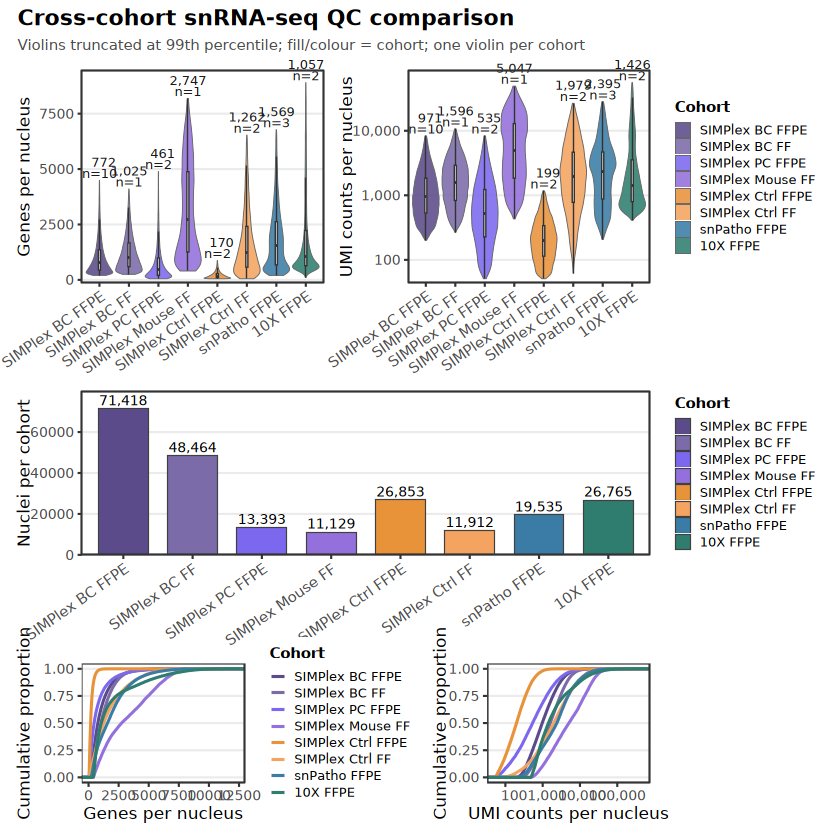

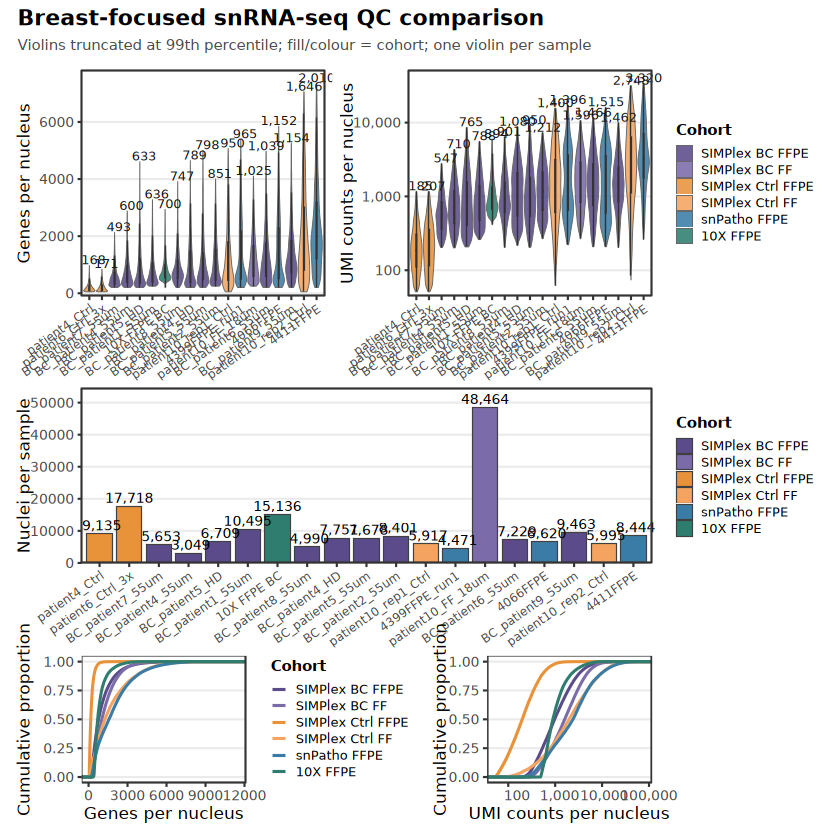

In [6]:
theme_pub <- function() {
  theme_bw(base_size = 10) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank(),
      strip.background = element_rect(fill = "grey95", color = NA),
      strip.text = element_text(face = "bold"),
      legend.position = "bottom",
      plot.title = element_text(face = "bold", size = 10),
      axis.title = element_text(size = 10)
    )
}

legend_theme_side <- function() {
  theme(
    legend.position = "right",
    legend.box = "vertical",
    legend.background = element_rect(fill = "white", color = NA),
    legend.key.size = grid::unit(0.35, "cm"),
    legend.text = element_text(size = 7.5),
    legend.title = element_text(size = 8.5, face = "bold"),
    plot.margin = margin(5, 6, 5, 5, "pt")
  )
}

VIOLIN_PCTL_CAP <- 0.99

order_x_levels <- function(df, x_var) {
  hint <- if (x_var == "cohort") COHORT_LEVELS else NULL
  out <- df %>%
    dplyr::group_by(.data[[x_var]]) %>%
    dplyr::summarise(median_genes = median(nFeature_RNA, na.rm = TRUE), .groups = "drop")
  if (!is.null(hint)) {
    out <- out %>% dplyr::mutate(.ord = match(.data[[x_var]], hint)) %>% dplyr::arrange(.ord, median_genes)
  } else {
    out <- out %>% dplyr::arrange(median_genes)
  }
  as.character(out[[x_var]])
}

summarise_for_x <- function(df, x_var) {
  df %>%
    dplyr::mutate(.x = as.character(.data[[x_var]])) %>%
    dplyr::group_by(cohort, .x) %>%
    dplyr::summarise(
      n_nuclei = dplyr::n(),
      n_samples = dplyr::n_distinct(sample_id),
      median_genes = median(nFeature_RNA, na.rm = TRUE),
      median_UMIs = median(nCount_RNA, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::rename(x = .x)
}

truncate_violin <- function(df, metric, x_col, p = VIOLIN_PCTL_CAP) {
  df %>%
    dplyr::group_by(.data[[x_col]]) %>%
    dplyr::filter(.data[[metric]] <= stats::quantile(.data[[metric]], p, na.rm = TRUE)) %>%
    dplyr::ungroup()
}

plot_qc_violin <- function(df, metric, ylab, x_col, x_levels, by_cohort = TRUE,
                           log_y = FALSE, show_labels = TRUE, show_legend = FALSE) {
  d <- df %>% dplyr::mutate(x = factor(.data[[x_col]], levels = x_levels))
  d_plot <- truncate_violin(d, metric, "x")
  stats <- d %>%
    dplyr::group_by(x, cohort) %>%
    dplyr::summarise(
      median = median(.data[[metric]], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::left_join(
      dplyr::summarise(dplyr::group_by(d_plot, x), y_top = max(.data[[metric]], na.rm = TRUE), .groups = "drop"),
      by = "x"
    ) %>%
    dplyr::left_join(summarise_for_x(df, x_col), by = c("x", "cohort"))

  p <- ggplot2::ggplot(d_plot, ggplot2::aes(x = x, y = .data[[metric]], fill = cohort)) +
    ggplot2::geom_violin(scale = "width", trim = TRUE, linewidth = 0.2, color = "grey40", alpha = 0.88) +
    ggplot2::geom_boxplot(width = 0.07, outlier.shape = NA, fill = "white", color = "grey20", linewidth = 0.3) +
    ggplot2::scale_fill_manual(values = COHORT_COLORS, name = "Cohort") +
    ggplot2::labs(x = NULL, y = ylab) +
    ggplot2::coord_cartesian(clip = "off") +
    theme_pub() +
    theme(axis.text.x = element_text(angle = 35, hjust = 1, size = if (x_col == "sample_id") 7 else 8.5))

  if (log_y) {
    p <- p + ggplot2::scale_y_log10(
      labels = function(x) format(x, scientific = FALSE, big.mark = ","),
      expand = ggplot2::expansion(mult = c(0.02, 0.06))
    )
  } else {
    p <- p + ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0.02, 0.06)))
  }

  if (show_labels) {
    stats <- stats %>% dplyr::mutate(
      label = if (x_col == "cohort") {
        sprintf("%s\nn=%d", format(round(median), big.mark = ","), n_samples)
      } else {
        format(round(median), big.mark = ",")
      }
    )
    p <- p + ggplot2::geom_text(
      data = stats, ggplot2::aes(x = x, y = y_top, label = label),
      inherit.aes = FALSE, size = 2.6, color = "grey10", lineheight = 0.75, vjust = -0.12
    )
  }
  if (!show_legend) p <- p + ggplot2::guides(fill = "none")
  if (show_legend) p <- p + legend_theme_side()
  p
}

build_qc_figure <- function(df, x_var, title, file_stem, width = 13, height = 12) {
  x_levels <- order_x_levels(df, x_var)
  df <- df %>% dplyr::mutate(x = factor(.data[[x_var]], levels = x_levels))
  qc_summary <- summarise_for_x(df, x_var)

  counts_df <- df %>% dplyr::count(x, cohort, name = "N")
  counts_df$x <- factor(counts_df$x, levels = x_levels)

  p_counts <- ggplot2::ggplot(counts_df, ggplot2::aes(x = x, y = N, fill = cohort)) +
    ggplot2::geom_col(color = "grey25", linewidth = 0.25, width = if (x_var == "cohort") 0.72 else 0.85) +
    ggplot2::geom_text(ggplot2::aes(label = format(N, big.mark = ",")), vjust = -0.35, size = 2.8) +
    ggplot2::scale_fill_manual(values = COHORT_COLORS, name = "Cohort") +
    ggplot2::scale_y_continuous(expand = ggplot2::expansion(mult = c(0, 0.12))) +
    ggplot2::labs(x = NULL, y = if (x_var == "cohort") "Nuclei per cohort" else "Nuclei per sample") +
    ggplot2::coord_cartesian(clip = "off") +
    theme_pub() +
    theme(axis.text.x = element_text(angle = 35, hjust = 1, size = if (x_var == "sample_id") 7 else 8.5)) +
    legend_theme_side()

  p_ecdf_genes <- ggplot2::ggplot(df, ggplot2::aes(x = nFeature_RNA, color = cohort)) +
    ggplot2::stat_ecdf(linewidth = 0.65) +
    ggplot2::scale_color_manual(values = COHORT_COLORS, name = "Cohort") +
    ggplot2::labs(x = "Genes per nucleus", y = "Cumulative proportion") +
    theme_pub() + legend_theme_side()

  p_ecdf_umis <- ggplot2::ggplot(df, ggplot2::aes(x = nCount_RNA, color = cohort)) +
    ggplot2::stat_ecdf(linewidth = 0.65) +
    ggplot2::scale_color_manual(values = COHORT_COLORS, guide = "none") +
    ggplot2::scale_x_log10(labels = function(x) format(x, scientific = FALSE, big.mark = ",")) +
    ggplot2::labs(x = "UMI counts per nucleus", y = "Cumulative proportion") +
    theme_pub()

  subtitle <- paste0(
    "Violins truncated at ", VIOLIN_PCTL_CAP * 100, "th percentile; fill/colour = cohort; ",
    if (x_var == "cohort") "one violin per cohort" else "one violin per sample"
  )

  p_out <- (
    plot_qc_violin(df, "nFeature_RNA", "Genes per nucleus", x_var, x_levels, show_legend = FALSE) |
    plot_qc_violin(df, "nCount_RNA", "UMI counts per nucleus", x_var, x_levels, log_y = TRUE, show_legend = TRUE)
  ) / p_counts / (p_ecdf_genes | p_ecdf_umis) +
    patchwork::plot_annotation(title = title, subtitle = subtitle,
      theme = theme(plot.title = element_text(face = "bold", size = 13),
                    plot.subtitle = element_text(size = 8.5, colour = "grey30"))) +
    patchwork::plot_layout(heights = c(1.1, 0.85, 0.62), widths = c(1, 1))

  ggplot2::ggsave(file.path(FIG_DIR, paste0(file_stem, ".pdf")), p_out, width = width, height = height)
  ggplot2::ggsave(file.path(FIG_DIR, paste0(file_stem, ".png")), p_out, width = width, height = height, dpi = 300)
  invisible(p_out)
}

write.csv(
  qc_meta %>% dplyr::group_by(cohort) %>% dplyr::summarise(
    n_samples = dplyr::n_distinct(sample_id),
    samples = paste(sort(unique(sample_id)), collapse = "; "),
    n_nuclei = dplyr::n(),
    median_genes = median(nFeature_RNA, na.rm = TRUE),
    median_UMIs = median(nCount_RNA, na.rm = TRUE),
    .groups = "drop"
  ),
  file.path(FIG_DIR, "qc_cohort_summary.csv"), row.names = FALSE
)

qc_meta_breast <- qc_meta %>% dplyr::filter(
  cohort %in% BREAST_FIGURE_COHORTS,
  cohort != "10X FFPE" | sample_id == "10X FFPE BC"
)

p_qc <- build_qc_figure(
  df = qc_meta,
  x_var = "cohort",
  title = "Cross-cohort snRNA-seq QC comparison",
  file_stem = "qc_cohort_comparison"
)

p_qc_breast <- build_qc_figure(
  df = qc_meta_breast,
  x_var = "sample_id",
  title = "Breast-focused snRNA-seq QC comparison",
  file_stem = "qc_breast_cohort_comparison",
  width = 14,
  height = 12
)

print(p_qc)
print(p_qc_breast)


## Session info


In [7]:
sessionInfo()


R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 9.8 (Plow)

Matrix products: default
BLAS/LAPACK: /srv/home/m.abreumachado/apps/miniconda3/envs/simplex/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Stockholm
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggplot2_3.5.2      patchwork_1.2.0    magrittr_2.0.4     stringr_1.5.1     
 [5] tidyr_1.3.1        dplyr_1.1.4        Matrix_1.6-5       Seurat_5.2.1      
 [9] SeuratObject_5.0.2 